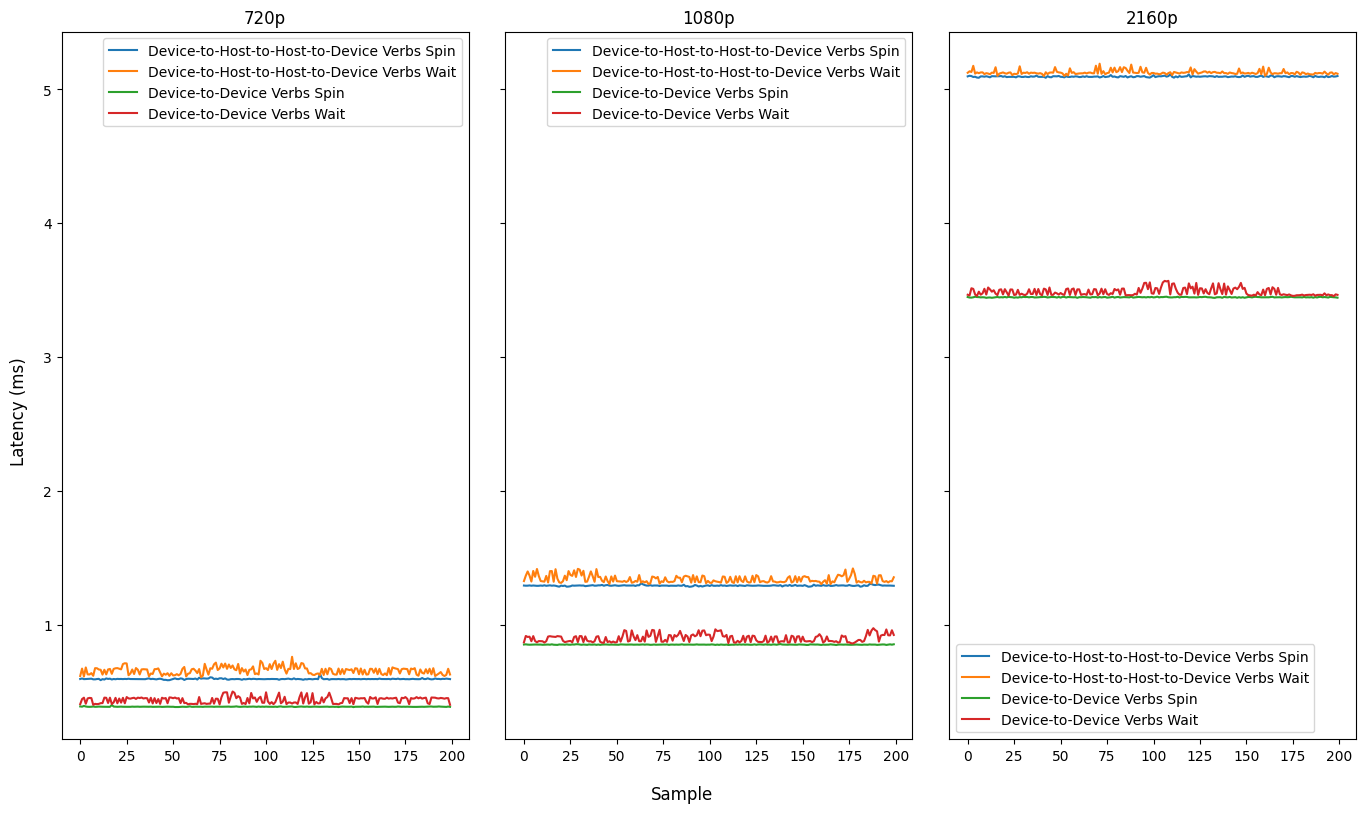

In [1]:
import polars as pl
import matplotlib.pyplot as plt

data_d2h2h2d_spin={}
data_d2h2h2d_wait={}
data_h2h_spin={}
data_h2h_wait={}
data_d2d_spin={}
data_d2d_wait={}

formats=[720, 1080, 2160]
for format in formats:
    data_d2h2h2d_spin[format]=pl.read_csv(f"../data/extra-copy/{format}/MXLFabrics+Cuda2Host2Host2Cuda+Verbs+Reflect+Spin.csv").select(pl.col("Timers"))
    data_d2h2h2d_wait[format]=pl.read_csv(f"../data/extra-copy/{format}/MXLFabrics+Cuda2Host2Host2Cuda+Verbs+Reflect+Wait.csv").select(pl.col("Timers"))
    data_h2h_spin[format]=pl.read_csv(f"../data/extra-copy/{format}/MXLFabrics+Host2Host+Verbs+Reflect+Spin.csv").select(pl.col("Timers"))
    data_h2h_wait[format]=pl.read_csv(f"../data/extra-copy/{format}/MXLFabrics+Host2Host+Verbs+Reflect+Wait.csv").select(pl.col("Timers"))
    data_d2d_spin[format]=pl.read_csv(f"../data/extra-copy/{format}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Spin.csv").select(pl.col("Timers"))
    data_d2d_wait[format]=pl.read_csv(f"../data/extra-copy/{format}/MXLFabrics+Cuda2Cuda+Verbs+Reflect+Wait.csv").select(pl.col("Timers"))

plt.rcParams['figure.figsize'] = [14,8]
fig, axs = plt.subplots(nrows=1,ncols=3, sharex=True, sharey=True)
fig.supylabel("Latency (ms)")
fig.supxlabel("Sample")
fig.tight_layout()

for i, img_size in enumerate(formats):
    axs[i].set_title(f"{img_size}p")
    #axs[i].set_ylim(0,2)
    axs[i].plot(data_d2h2h2d_spin[img_size]/1e6/2, label=f"Device-to-Host-to-Host-to-Device Verbs Spin")
    axs[i].plot(data_d2h2h2d_wait[img_size]/1e6/2, label=f"Device-to-Host-to-Host-to-Device Verbs Wait")
    #axs[i].plot(data_h2h_spin[img_size]/1e6/2, label=f"Host-to-Host Verbs Spin")
    #axs[i].plot(data_h2h_wait[img_size]/1e6/2, label=f"Host-to-Host Verbs Wait")
    axs[i].plot(data_d2d_spin[img_size]/1e6/2, label=f"Device-to-Device Verbs Spin")
    axs[i].plot(data_d2d_wait[img_size]/1e6/2, label=f"Device-to-Device Verbs Wait")
    axs[i].legend()
